# Titanic Survival Prediction
 predicting who survived using EDA+ Machine learning

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### load the data set

In [2]:
PATH = "/kaggle/input/titanic/" if os.path.exists("/kaggle") else "./data/titanic/"
train =pd.read_csv(PATH + 'train.csv')
test = pd.read_csv(PATH + 'test.csv')
print('Train Shape:', train.shape)
print('Test Shape:', test.shape)
print('Train Head:', train.head())

Train Shape: (891, 12)
Test Shape: (418, 11)
Train Head:    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S 

### Exploratory Data Analysis
Exploring the data visually to understand which features predict survival


In [3]:
print('Missing value in Train:')
print(train.isnull().sum())
print('-------')
print('Missing value in test:')
print(test.isnull().sum())

Missing value in Train:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
-------
Missing value in test:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


### EDA charts

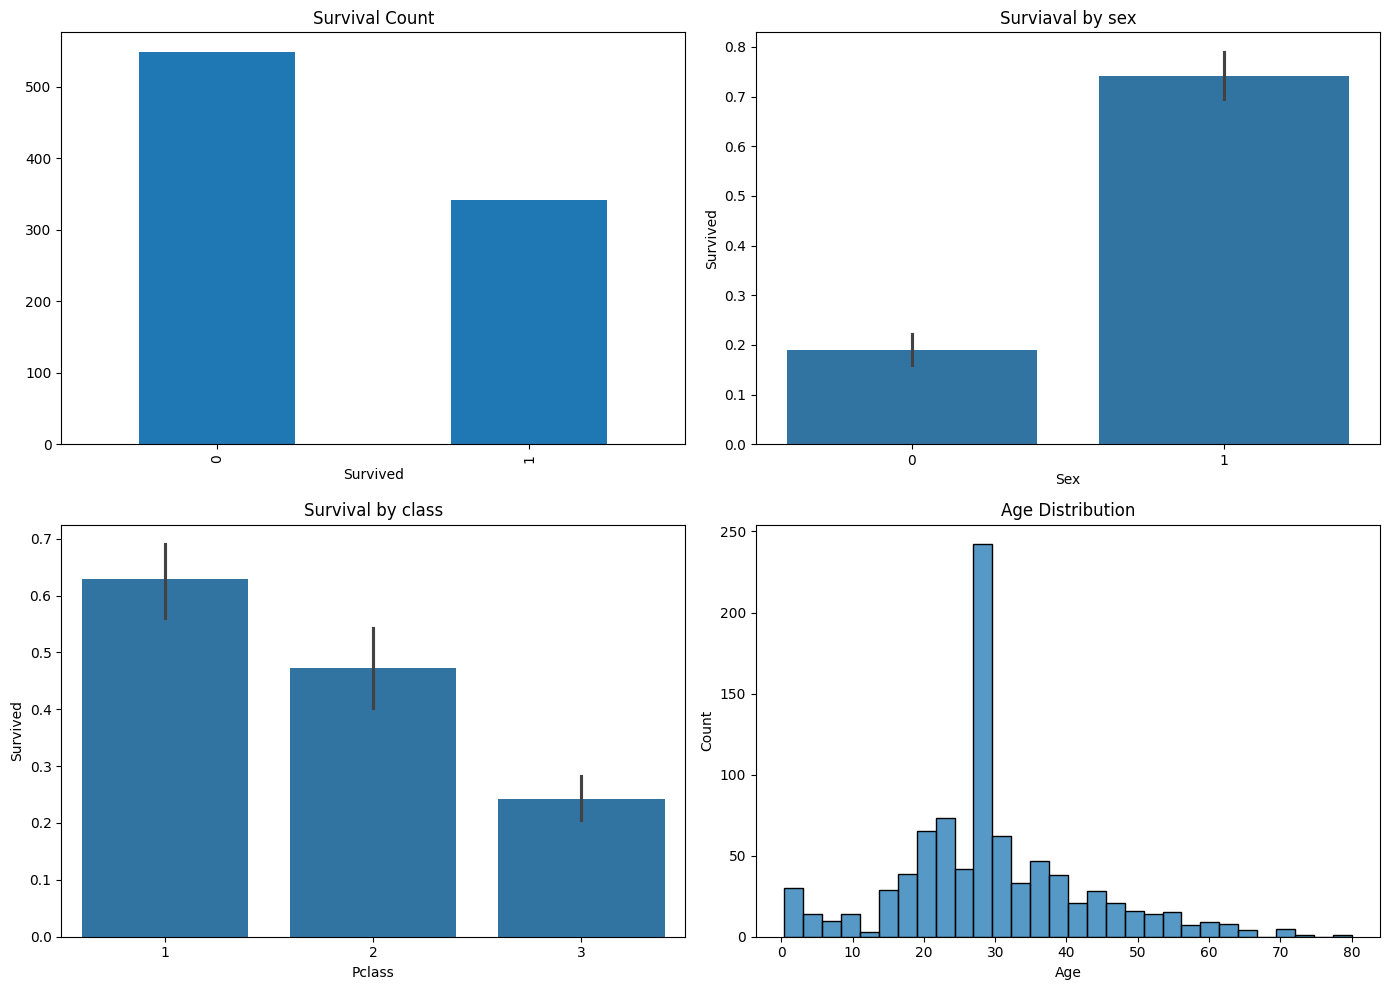

In [11]:
fig,axes = plt.subplots(2,2, figsize=(14, 10))

train['Survived'].value_counts().plot(kind='bar',ax=axes[0,0])
axes[0,0].set_title('Survival Count')

sns.barplot(data=train, x ='Sex' , y= 'Survived', ax=axes[0,1])
axes[0,1].set_title('Surviaval by sex')

sns.barplot(data=train, x='Pclass', y='Survived', ax=axes[1,0])
axes[1,0].set_title('Survival by class')

sns.histplot(train['Age'].dropna(), bins=30, ax=axes[1,1])
axes[1,1].set_title('Age Distribution')

plt.tight_layout()
plt.show()

### Obsevations 
-women survived at a much higher rate than men (-74% vs 19%)
- 1st class passengers survived more than 3rd c;ass (63% vs 24%)
- most passengers were age between 20 and 40
- data is slightly imbalanced - more deaths than survivals

### Feature Engineering
-cleaning missing values and creating new features for the model

In [5]:
def engineer_features(df):
    df=df.copy()
    df['Age']= df['Age'].fillna(df['Age'].median())
    df['Embarked']= df['Embarked'].fillna('S')
    df['Fare']= df['Fare'].fillna(df['Fare'].median())
    df['FamilySize']=df['SibSp'] + df['Parch'] +1
    df['Sex']=df['Sex'].map({'male':0, 'female':1})
    df['Embarked']= df['Embarked'].map({'S':0, 'C':1,'Q':2})
    return df

In [6]:
train = engineer_features(train)
test = engineer_features(test)

### Modeling
- Training a Random Forest Classifier with cross validation

In [7]:

FEATURES =['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize']
X=train[FEATURES]
y=train['Survived']
model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
cv_score = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(f'CV Accuracy: {cv_score.mean(): .4f} ± {cv_score.std(): .4f}')

CV Accuracy:  0.8182 ±  0.0229


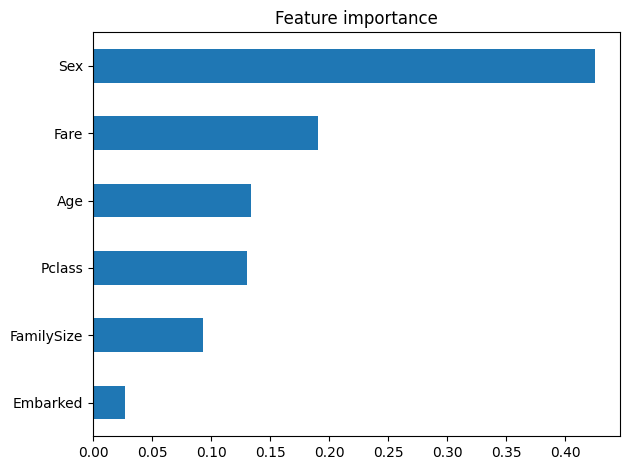

In [8]:
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=FEATURES)
importances.sort_values().plot(kind='barh', title='Feature importance')
plt.tight_layout()
plt.show()

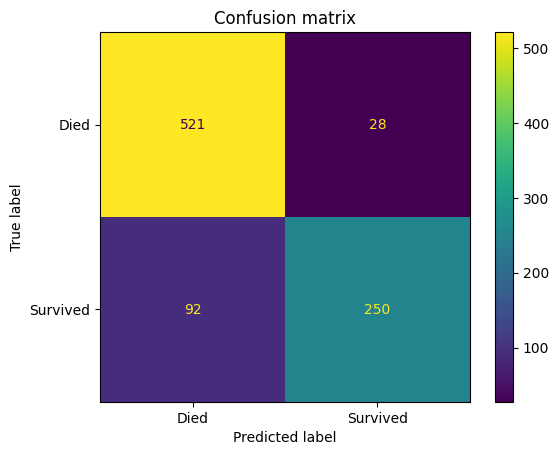

In [9]:
y_pred = model.predict(X)
cm = confusion_matrix(y, y_pred) 
disp = ConfusionMatrixDisplay(cm, display_labels=['Died', 'Survived'])
disp.plot()
plt.title('Confusion matrix')
plt.show()

In [10]:
## Submission File
preds = model.predict(test[FEATURES])

submission =pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': preds
})

submission.to_csv('Submission.csv', index=False)
print('Done!')
submission.head()


Done!


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


### Conclusion
- Achived CV accuracy of 81.82%
- Sex and Fare were strongest predictors
- next step: try XGBoost, and Title feature